In [4]:
#source('/research_jude/rgs01_jude/groups/jxugrp/home/common/Lab_Members/WenhuoHu/script/utils.r')
base_dir = '/scratch/mjehangir/manuscript_figures/manuscript_data/'
setwd(base_dir)

In [6]:
# Load required libraries
library(tidyverse)
library(corrplot)
library(ggpubr)
library(tidyverse)
library(readxl)
library(DESeq2)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(ggrepel)
library(ComplexHeatmap)
library(tidyr)
library(dplyr)
library(GGally)
library(data.table)  # For fread()

In [7]:
final_df = read.csv(file = "final_merged_for_correlation_analysis_v3.tsv", header = TRUE, sep = "\t")

In [8]:
nrow(final_df)

[1] 1155

In [9]:
head(final_df)

,SampleID,assigned_arm,chr,Length,total_length_neutral,total_length_gain,total_length_loss,proportion_neutral,proportion_gain,proportion_loss,final_average_TL_p75,chr_order,arm,arm_call,arm_num_seg,arm_cr_wmean,type,total_size,SVs_density
,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>
1,2436A,chr10q,chr10,94108943,26230785,0,18621836,0.27872787,0,0.1978753,2732.75,10,q,0,5,0.9870386,DEL,159358,0.0016933354
2,2436A,chr10q,chr10,94108943,26230785,0,18621836,0.27872787,0,0.1978753,2732.75,10,q,0,5,0.9870386,DUP,23673,0.0002515489
3,2436A,chr11p,chr11,52743313,3002850,0,0,0.05693328,0,0.0000000,6766.00,11,p,0,6,1.0067300,DEL,104279,0.0019771037
4,2436A,chr12p,chr12,35911664,4003740,0,0,0.11148857,0,0.0000000,5319.40,12,p,0,2,1.0909572,DEL,68002,0.0018935909
5,2436A,chr12p,chr12,35911664,4003740,0,0,0.11148857,0,0.0000000,5319.40,12,p,0,2,1.0909572,INV,99738133,2.7773186171
6,2436A,chr12q,chr12,97412884,9809163,0,0,0.10069677,0,0.0000000,6085.00,12,q,0,10,1.0029376,DEL,164131,0.0016849003


In [10]:
# Load required libraries
library(data.table)      # if your final_df is a data.table
library(dplyr)           # for data manipulation
library(ComplexHeatmap)  # for plotting the heatmap
library(circlize)        # for the color mapping with colorRamp2

# Assume final_df is your data.table with columns: 
# SampleID, chr, arm, SV_density, proportion_gain, proportion_loss, 
# final_average_TL_p75, arm_call, arm_num_seg, arm_cr_wmean, etc.

# Optional: convert final_df to a tibble (if you prefer dplyr piping)
final_df <- as_tibble(final_df)


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))




In [11]:
head(final_df, n=55)

SampleID,assigned_arm,chr,Length,total_length_neutral,total_length_gain,total_length_loss,proportion_neutral,proportion_gain,proportion_loss,final_average_TL_p75,chr_order,arm,arm_call,arm_num_seg,arm_cr_wmean,type,total_size,SVs_density
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<int>,<int>,<dbl>,<chr>,<dbl>,<dbl>
2436A,chr10q,chr10,94108943,26230785,0,18621836,0.27872787,0.000000000,0.197875307,2732.750,10,q,0,5,0.9870386,DEL,159358,1.693335e-03
2436A,chr10q,chr10,94108943,26230785,0,18621836,0.27872787,0.000000000,0.197875307,2732.750,10,q,0,5,0.9870386,DUP,23673,2.515489e-04
2436A,chr11p,chr11,52743313,3002850,0,0,0.05693328,0.000000000,0.000000000,6766.000,11,p,0,6,1.0067300,DEL,104279,1.977104e-03
2436A,chr12p,chr12,35911664,4003740,0,0,0.11148857,0.000000000,0.000000000,5319.400,12,p,0,2,1.0909572,DEL,68002,1.893591e-03
2436A,chr12p,chr12,35911664,4003740,0,0,0.11148857,0.000000000,0.000000000,5319.400,12,p,0,2,1.0909572,INV,99738133,2.777319e+00
2436A,chr12q,chr12,97412884,9809163,0,0,0.10069677,0.000000000,0.000000000,6085.000,12,q,0,10,1.0029376,DEL,164131,1.684900e-03
2436A,chr12q,chr12,97412884,9809163,0,0,0.10069677,0.000000000,0.000000000,6085.000,12,q,0,10,1.0029376,INV,21374425,2.194209e-01
2436A,chr14q,chr14,89761231,1001600,0,0,0.01115849,0.000000000,0.000000000,3490.600,14,q,0,11,1.0114610,DEL,122578,1.365601e-03
2436A,chr15q,chr15,82566565,0,1602464,0,0.00000000,0.019408147,0.000000000,4111.500,15,q,0,3,0.9820486,DEL,102780,1.244814e-03


In [12]:
# Ensure proper chromosome ordering: extract numeric part from the 'chr' column
final_df <- final_df %>%
  mutate(chrom_num = as.numeric(gsub("chr", "", chr)))

# Define the features of interest
features <- c( "proportion_gain", "proportion_loss", "arm_cr_wmean", "INS_density",	"DEL_density", "DUP_density", "INV_density")

# Revised helper function that checks for complete pairs before computing correlation
get_corr_matrix <- function(data, features, chroms = 1:22) {
  
  # Initialize an empty matrix to store correlations
  corr_matrix <- matrix(NA, nrow = length(features), ncol = length(chroms),
                        dimnames = list(features, paste0("chr", chroms)))
  
  for (ch in chroms) {
    sub_data <- data %>% filter(chrom_num == ch)
    
    # Optionally check if there are at least 3 rows overall
    if (nrow(sub_data) >= 3) {
      for (f in features) {
        # Identify complete cases for the two variables
        complete_idx <- complete.cases(sub_data[[f]], sub_data$final_average_TL_p75)
        # Only compute correlation if there are at least 2 complete pairs
        if (sum(complete_idx) >= 2) {
          r_val <- cor(sub_data[[f]][complete_idx], sub_data$final_average_TL_p75[complete_idx])
        } else {
          r_val <- NA
        }
        corr_matrix[f, paste0("chr", ch)] <- r_val
      }
    } else {
      # Not enough rows for this chromosome; correlations remain as NA
      for (f in features) {
        corr_matrix[f, paste0("chr", ch)] <- NA
      }
    }
  }
  
  return(corr_matrix)
}


In [13]:
# Create separate datasets for p arm and q arm
p_arm <- final_df %>% filter(arm == "p")
q_arm <- final_df %>% filter(arm == "q")

# Compute the correlation matrices for each arm
corr_matrix_p <- get_corr_matrix(p_arm, features)
corr_matrix_q <- get_corr_matrix(q_arm, features)

ERROR: Error in cor(sub_data[[f]][complete_idx], sub_data$final_average_TL_p75[complete_idx]): 'x' must be numeric


In [14]:
head(corr_matrix_p)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': object 'corr_matrix_p' not found


In [15]:
# Define the color function for the heatmap: blue for negative, white for zero, red for positive correlations
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))


In [16]:
head(corr_matrix_p, n=2)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': object 'corr_matrix_p' not found


In [17]:
# Remove the "SV_density" row and columns "chr13", "chr14", "chr15", "chr22"
corr_matrix_p <- corr_matrix_p[
  rownames(corr_matrix_p) != "SV_density",
  !(colnames(corr_matrix_p) %in% c("chr13", "chr14", "chr15", "chr22"))
]


ERROR: Error: object 'corr_matrix_p' not found


In [18]:

options(repr.plot.width = 12, repr.plot.height = 3, repr.plot.res = 200)

Heatmap(
  corr_matrix_p,
  name = "Correlation",
  col = col_fun,
  cluster_rows = FALSE,        # preserve feature order
  cluster_columns = FALSE,     # preserve chromosome order
  column_title = "p arm: Telomere lenght vs Variant features",
  row_title = "Feature vs final_average_TL_p75",
  heatmap_legend_param = list(title = "r"),
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Add the correlation value (formatted to 2 decimal places) in the center of the cell
    grid.text(sprintf("%.2f", corr_matrix_p[i, j]), x, y, gp = gpar(fontsize = 10))
    
    # Draw a black border around the cell
    grid.rect(x = x, y = y, width = width, height = height,
              gp = gpar(col = "black", fill = NA, lwd = 0.5))
  }
)


ERROR: Error: object 'corr_matrix_p' not found


In [19]:
options(repr.plot.width = 12, repr.plot.height = 3, repr.plot.res = 200)

Heatmap(
  corr_matrix_q,
  name = "Correlation",
  col = col_fun,
  cluster_rows = FALSE,        # preserve feature order
  cluster_columns = FALSE,     # preserve chromosome order
  column_title = "q arm:  Telomere lenght vs Variant features",
  row_title = "Feature vs final_average_TL_p75",
  heatmap_legend_param = list(title = "r"),
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Add the correlation value formatted to 2 decimal places in the center of the cell
    grid.text(sprintf("%.2f", corr_matrix_q[i, j]), x, y, gp = gpar(fontsize = 10))
    
    # Draw a black border around the cell
    grid.rect(x = x, y = y, width = width, height = height,
              gp = gpar(col = "black", fill = NA, lwd = 0.5))
  }
)


ERROR: Error: object 'corr_matrix_q' not found


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


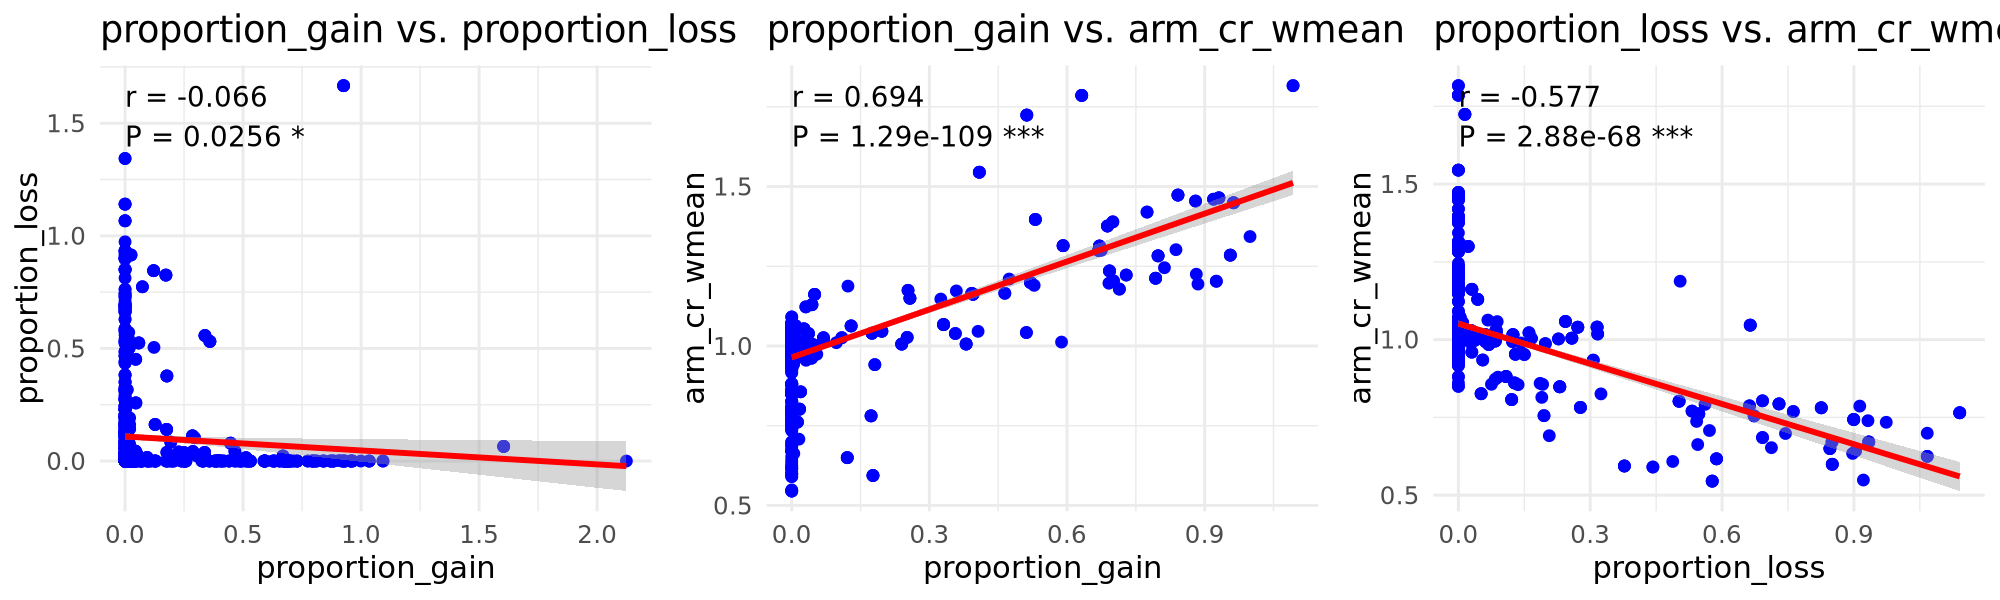

In [20]:

    # Define your variables
varnames <- c("proportion_gain", "proportion_loss", "arm_cr_wmean")

# Store plots in a list
plot_list <- list()

# Function to assign stars based on p-value
get_significance_stars <- function(p) {
  if (p < 0.001) return("***")  # Highly significant
  else if (p < 0.01) return("**")  # Significant
  else if (p < 0.05) return("*")  # Marginally significant
  else return("ns")  # Not significant
}

# Loop over each unique pair of variables
for (i in 1:(length(varnames) - 1)) {
  for (j in (i + 1):length(varnames)) {
    
    # Subset data and remove NAs
    temp_data <- final_df[, c(varnames[i], varnames[j]), drop = FALSE]
    temp_data <- na.omit(temp_data)
    
    # Ensure enough data points
    if (nrow(temp_data) > 2) {
        # Compute correlation and p-value
      cor_test <- cor.test(temp_data[[varnames[i]]], temp_data[[varnames[j]]], method = "pearson")
      corr_value <- round(cor_test$estimate, 3)
      p_value <- signif(cor_test$p.value, 3)
      
      # Get significance stars
      significance <- get_significance_stars(p_value)
        
              options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 200)

      # Create scatter plot
      p <- ggplot(temp_data, aes_string(x = varnames[i], y = varnames[j])) +
        geom_point(color = "blue") + 
        geom_smooth(method = "lm", se = TRUE, color = "red") +
        labs(title = paste(varnames[i], "vs.", varnames[j]),
             x = varnames[i], y = varnames[j]) +
        annotate("text", x = min(temp_data[[varnames[i]]]), y = max(temp_data[[varnames[j]]]), 
                 label = paste("r =", corr_value, "\nP =", p_value, significance), 
                 hjust = 0, vjust = 1, color = "black", size = 3.5) +
        theme_minimal()
      
      # Store plot in list
      plot_list[[length(plot_list) + 1]] <- p
    } else {
      message(paste("Not enough data to plot", varnames[i], "vs.", varnames[j]))
    }
  }
}

# Arrange plots in a grid (3 plots per row)
ggarrange(plotlist = plot_list, ncol = 3, nrow = ceiling(length(plot_list) / 8))

In [21]:
# Filter data for chromosome 9 p arm
df_p_chr9 <- final_df[final_df$chr == "chr9" & final_df$arm == "p", ]

# Perform Pearson correlation test
cor_test <- cor.test(df_p_chr9$SV_density, df_p_chr9$final_average_TL_p75, method = "pearson")

# Extract correlation coefficient and p-value
cor_value <- round(cor_test$estimate, 3)
p_value <- signif(cor_test$p.value, 3)



options(repr.plot.width = 4, repr.plot.height = 5, repr.plot.res = 200)

# Create scatter plot
ggplot(df_p_chr9, aes(x = SV_density, y = final_average_TL_p75)) +
  geom_point(color = "blue", size = 5, alpha = 0.7) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(
    title = "Pearson Correlation between SV Density and TL_p75 (Chr9 p arm)",
    x = "SV Density",
    y = "Final Average TL_p75"
  ) +
  annotate("text", x = max(df_p_chr9$SV_density, na.rm = TRUE), 
           y = min(df_p_chr9$final_average_TL_p75, na.rm = TRUE), 
           label = paste0("r = ", cor_value, "\n p = ", p_value),
           hjust = 1, vjust = 0, size = 5, color = "black")


Warning message:
“Unknown or uninitialised column: `SV_density`.”


ERROR: Error in cor.test.default(df_p_chr9$SV_density, df_p_chr9$final_average_TL_p75, : 'x' must be a numeric vector


`geom_smooth()` using formula = 'y ~ x'


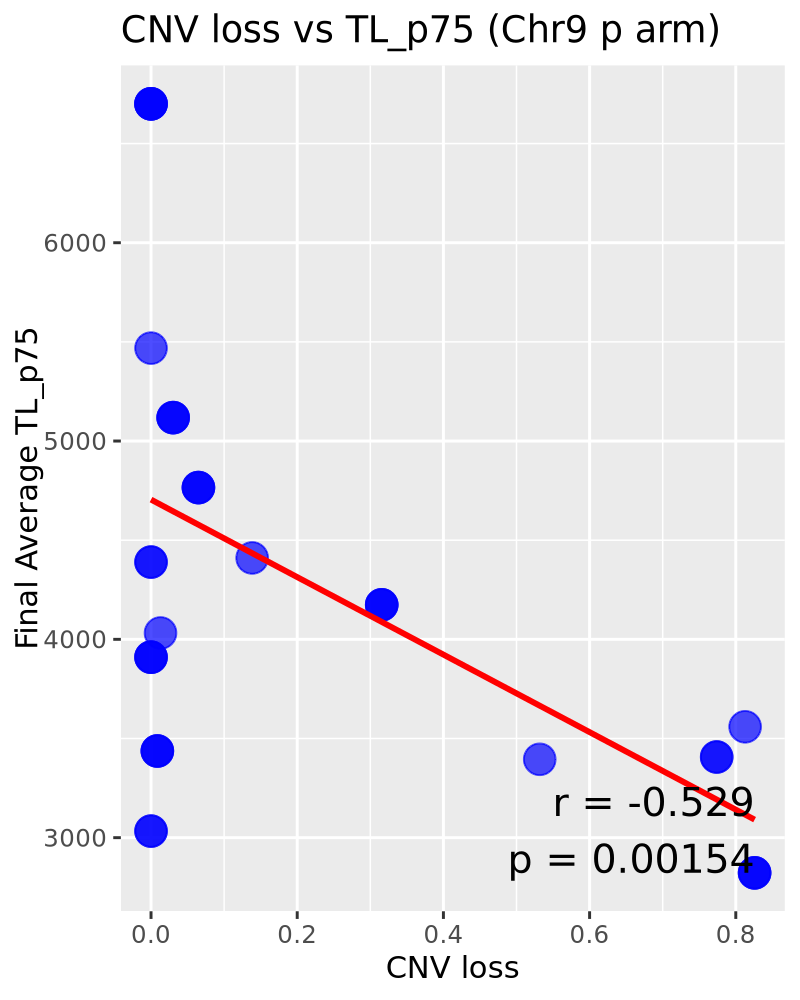

In [22]:
# Filter data for chromosome 9 p arm
df_p_chr9 <- final_df[final_df$chr == "chr9" & final_df$arm == "p", ]

# Perform Pearson correlation test
cor_test <- cor.test(df_p_chr9$proportion_loss, df_p_chr9$final_average_TL_p75, method = "pearson")

# Extract correlation coefficient and p-value
cor_value <- round(cor_test$estimate, 3)
p_value <- signif(cor_test$p.value, 3)



options(repr.plot.width = 4, repr.plot.height = 5, repr.plot.res = 200)

# Create scatter plot
ggplot(df_p_chr9, aes(x = proportion_loss, y = final_average_TL_p75)) +
  geom_point(color = "blue", size = 5, alpha = 0.7) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  labs(
    title = "CNV loss vs TL_p75 (Chr9 p arm)",
    x = "CNV loss",
    y = "Final Average TL_p75"
  ) +
  annotate("text", x = max(df_p_chr9$proportion_loss, na.rm = TRUE), 
           y = min(df_p_chr9$final_average_TL_p75, na.rm = TRUE), 
           label = paste0("r = ", cor_value, "\n p = ", p_value),
           hjust = 1, vjust = 0, size = 5, color = "black")

In [83]:
head(df_p_chr9)

SampleID,chr,arm,SV_density,proportion_gain,proportion_loss,final_average_TL_p75,arm_call,arm_num_seg,arm_cr_wmean,INS_density,DEL_density,DUP_density,INV_density,BND_density,chrom_num
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
3188,chr9,p,0.03507529,0.1729286,0.82573411,2822.5,-1,3,0.7808765,0,0.03401240,0.0003542958,0.0007085917,0,9
6423A,chr9,p,0.04042659,0.0000000,0.01296965,4032.0,-1,NA,NA,0,0.04042659,0.0000000000,0.0000000000,0,9


SV Type: Insertion - Not enough data to compute correlation.



`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


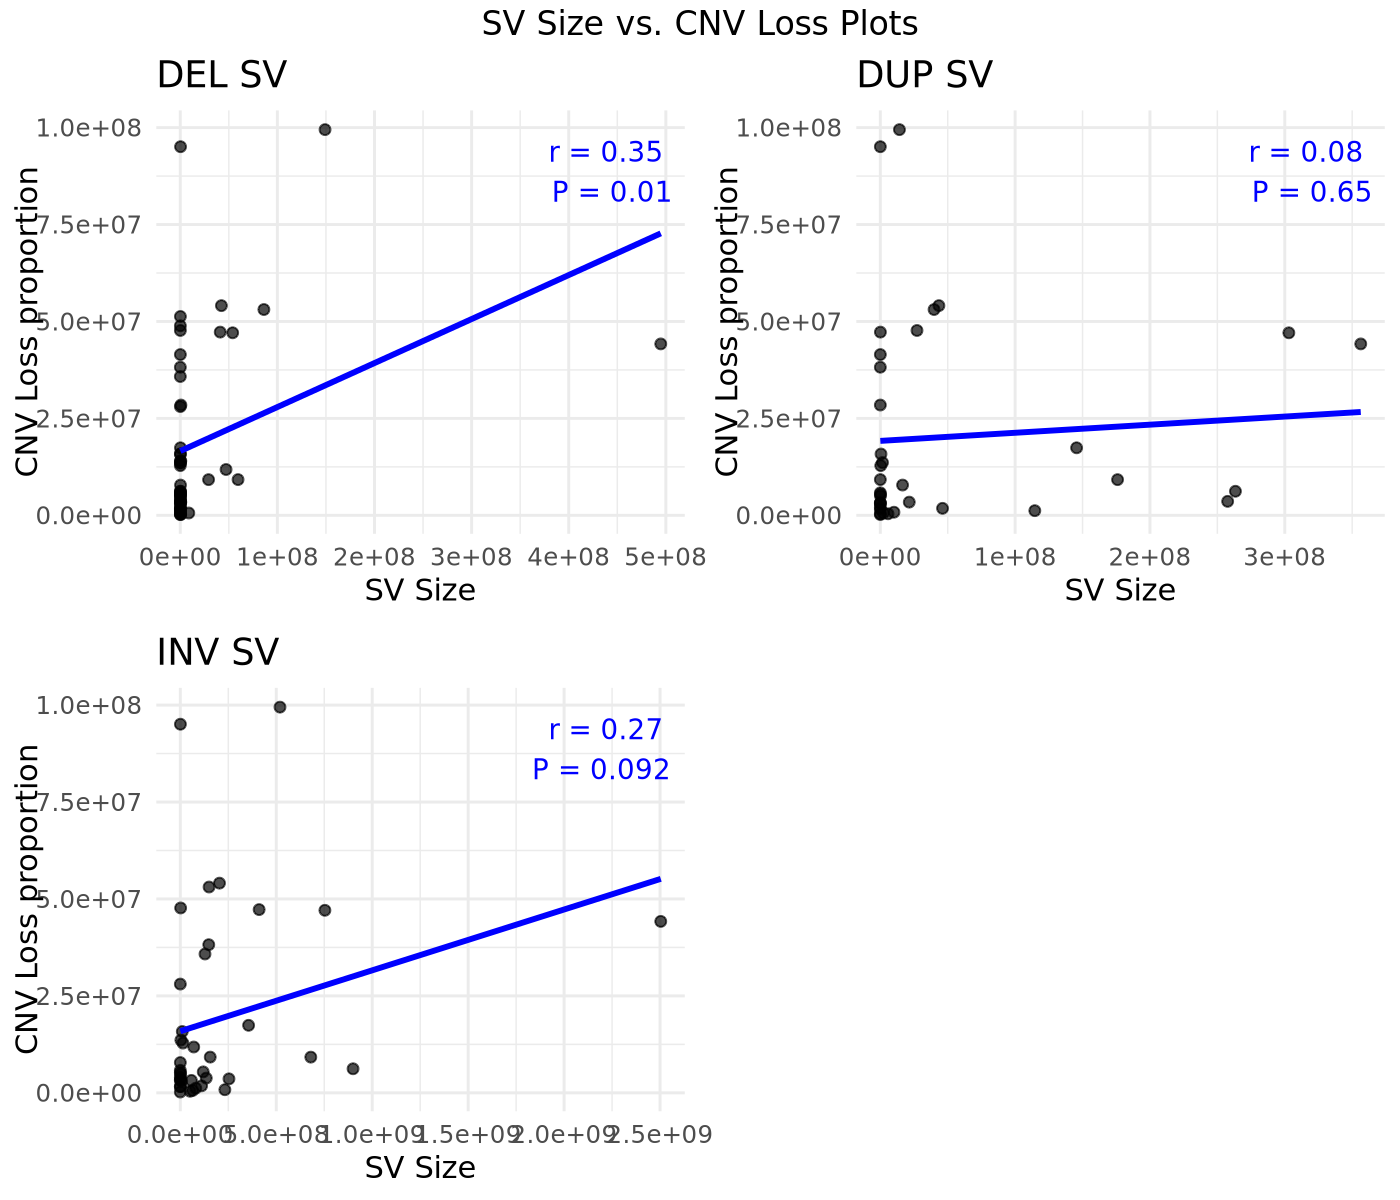

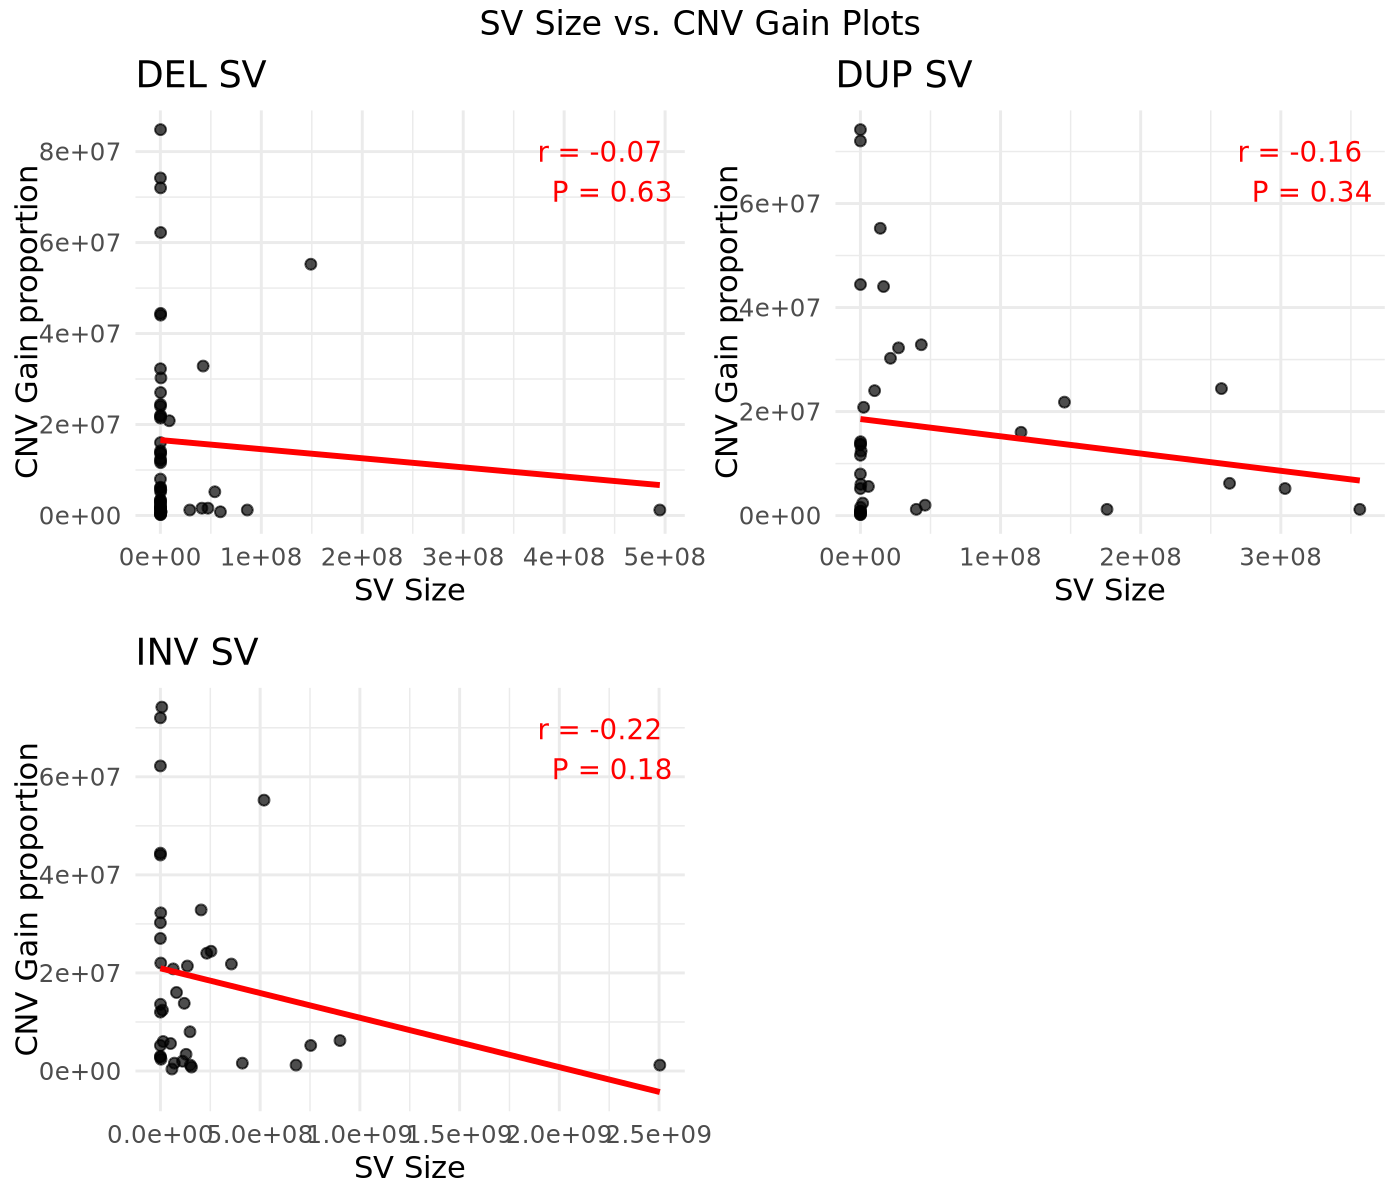

In [40]:
# Load necessary libraries
library(dplyr)
library(ggplot2)
library(gridExtra)

# --- Load your data ---
# Ensure your data is loaded into final_df. For example:
# final_df <- read.table("your_dataset.tsv", header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# --- Define allowed SV types ---
allowed_sv_types <- c("DEL", "DUP", "INV", "Insertion")

# Filter dataset to include only the allowed SV types
final_df_filtered <- final_df %>%
  filter(type %in% allowed_sv_types)

# --- Filter out rows where 'total_size', 'total_length_loss', or 'total_length_gain' are zero ---
final_df_filtered <- final_df_filtered %>%
  filter(total_size > 1000, total_length_loss != 0, total_length_gain != 0)

# --- Create empty lists to store plots ---
loss_plots <- list()
gain_plots <- list()

# Function to calculate correlation and p-value
correlation_test <- function(x, y) {
  #test <- cor.test(x, y, method = "spearman")
    test <- cor.test(x, y, method = "pearson")
  list(correlation = test$estimate, p_value = test$p.value)
}

# Loop through each allowed SV type and generate the plots
for (sv in allowed_sv_types) {
  sv_data <- final_df_filtered %>% filter(type == sv)
  
  if (nrow(sv_data) > 2) {  # Ensure there are enough data points
    # Calculate correlation and p-value for CNV Loss
    loss_test <- correlation_test(sv_data$total_size, sv_data$total_length_loss)
    loss_corr <- loss_test$correlation
    loss_pval <- loss_test$p_value
    
    # Create scatter plot for CNV Loss vs. SV Size
    p_loss <- ggplot(sv_data, aes(x = total_size, y = total_length_loss)) +
      geom_point(alpha = 0.7) +
      geom_smooth(method = "lm", se = FALSE, color = "blue") +
      labs(title = paste(sv, "SV"),
           x = "SV Size",
           y = "CNV Loss proportion") +
      theme_minimal() +
      annotate("text", x = Inf, y = Inf, label = paste("r =", round(loss_corr, 2), "\nP =", format.pval(loss_pval, digits = 2)), 
               hjust = 1.1, vjust = 1.5, size = 3.5, color = "blue")
    
    loss_plots[[sv]] <- p_loss
    
    # Calculate correlation and p-value for CNV Gain
    gain_test <- correlation_test(sv_data$total_size, sv_data$total_length_gain)
    gain_corr <- gain_test$correlation
    gain_pval <- gain_test$p_value
    
    # Create scatter plot for CNV Gain vs. SV Size
    p_gain <- ggplot(sv_data, aes(x = total_size, y = total_length_gain)) +
      geom_point(alpha = 0.7) +
      geom_smooth(method = "lm", se = FALSE, color = "red") +
      labs(title = paste(sv, "SV"),
           x = "SV Size",
           y = "CNV Gain proportion") +
      theme_minimal() +
      annotate("text", x = Inf, y = Inf, label = paste("r =", round(gain_corr, 2), "\nP =", format.pval(gain_pval, digits = 2)), 
               hjust = 1.1, vjust = 1.5, size = 3.5, color = "red")
    
    gain_plots[[sv]] <- p_gain
  } else {
    cat("SV Type:", sv, "- Not enough data to compute correlation.\n\n")
  }
}

# --- Arrange and display the plots ---
# Arrange the 4 loss plots in a 2x2 grid
grid.arrange(grobs = loss_plots, nrow = 2, ncol = 2, top = "SV Size vs. CNV Loss Plots")

# Arrange the 4 gain plots in a 2x2 grid
grid.arrange(grobs = gain_plots, nrow = 2, ncol = 2, top = "SV Size vs. CNV Gain Plots")
options(repr.plot.width = 7, repr.plot.height = 6, repr.plot.res = 200)
